In [81]:
import pandas as pd
import matplotlib.pyplot as plt 
import scipy
import tensorflow as tf

# O dataset usado é o MIT-BIH ECG dataset
Pra facilitar, o proprio scipy ja disponibilza o uso do dataset atraves de um metodo da biblioteca

"The provided signal is an excerpt (19:35 to 24:35) from the record 208 (lead MLII) provided by the MIT-BIH Arrhythmia Database on PhysioNet.

The excerpt includes noise induced artifacts, typical heartbeats as well as pathological changes."

Its a 1-D 5 minute long signal sampled at a 360Hz frequency (360 datapoints per second)

In [82]:
ecg = scipy.datasets.electrocardiogram()

<Axes: >

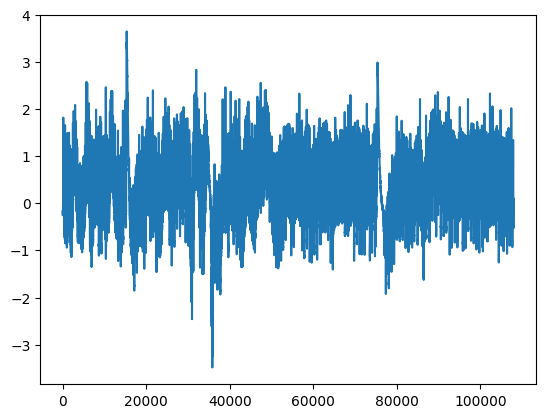

In [83]:
ecg = pd.Series(ecg)
ecg.plot()

Text(0.5, 1.0, '3 seconds of ecg data')

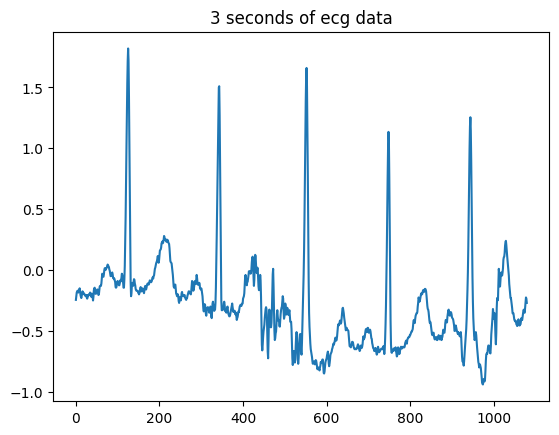

In [84]:
threeSecEcg = ecg[:360*3]
threeSecEcg.plot()
plt.title('3 seconds of ecg data')

## finding the R waves

In [85]:
r_waves, metadata = scipy.signal.find_peaks(threeSecEcg, height=1.0)

In [86]:
r_waves

array([125, 343, 552, 748, 944])

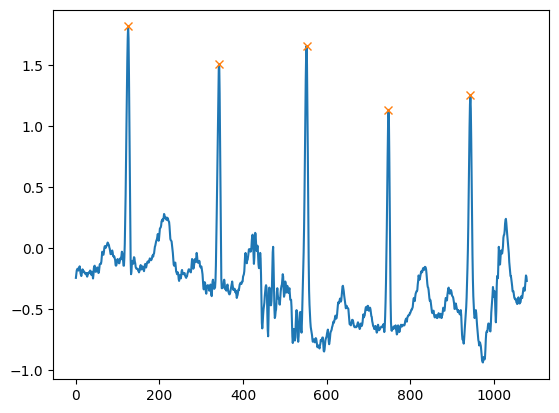

In [87]:
threeSecEcg.plot()
plt.plot(r_waves, threeSecEcg[r_waves], 'x')

# Now using the actual MIT BIH ECG dataset

it contains 48 half-hour excerpts of two-channel ambulatory recordings, each from one of the 47 different patients. It contains two channels (two leads?) with 11-bit resolution over a 10 mV range(????)

#### important

a single register is a group of files regarding the same l1_l1_l1_l1_l1_l1_l1_l1_signal, not a single file

inthis case, we have:

.dat -> raw signal

.hea -> info abt the signal

.atr -> beats annotations

In [88]:
import wfdb

In [89]:
record = wfdb.rdrecord(
    r"C:\Users\Larissa\bsi\IC\databases\ecg\mit-bih-arrhythmia-database-1.0.0\100"
    ) #selecting an specific record

ann = wfdb.rdann(r"C:\Users\Larissa\bsi\IC\databases\ecg\mit-bih-arrhythmia-database-1.0.0\100"
                 , "atr") #the record's annotation


In [90]:
print(record.fs, "   -> frequency") #returns the frequency of the record
print(record.sig_name, "   -> the name of the signal") #returns the name of the signal
print(record.p_signal.shape, "   -> the shape of the signal, that is the amount of points(?)") #returns the shape of the signal, that is the amount of points?

360    -> frequency
['MLII', 'V5']    -> the name of the signal
(650000, 2)    -> the shape of the signal, that is the amount of points(?)


#### plotting the ecg

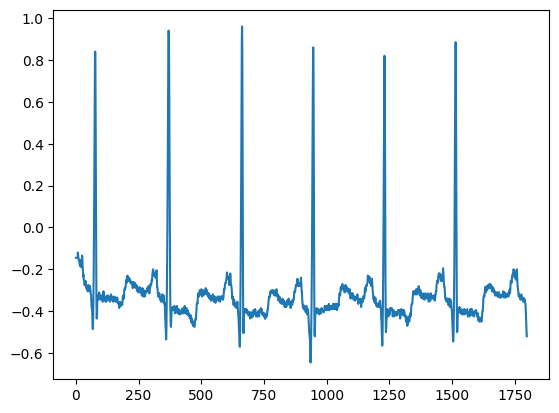

In [91]:
import matplotlib.pyplot as plt
l1_signal = record.p_signal[:,0] #gets all datapoints of only the lead1 signal

plt.plot(l1_signal[:5*360]) #only gets the first 5 sec of the recording, that is 5*360 = 1800 datapoints
plt.show()

In [92]:
x = 9
print(ann.symbol[x]) #x first beats?
print(set(ann.symbol)) #
#wfdb.io.show_ann_labels()

N
{'V', '+', 'A', 'N'}


In [93]:
wfdb.io.show_ann_labels()

    label_store symbol                                    description
0             0                              Not an actual annotation
1             1      N                                    Normal beat
2             2      L                  Left bundle branch block beat
3             3      R                 Right bundle branch block beat
4             4      a                Aberrated atrial premature beat
5             5      V              Premature ventricular contraction
6             6      F          Fusion of ventricular and normal beat
7             7      J              Nodal (junctional) premature beat
8             8      A                   Atrial premature contraction
9             9      S     Premature or ectopic supraventricular beat
10           10      E                        Ventricular escape beat
11           11      j                 Nodal (junctional) escape beat
12           12      /                                     Paced beat
13           13     

#### associating signal and annotation

In [94]:
idx = ann.sample[x]
idx

np.int64(2402)

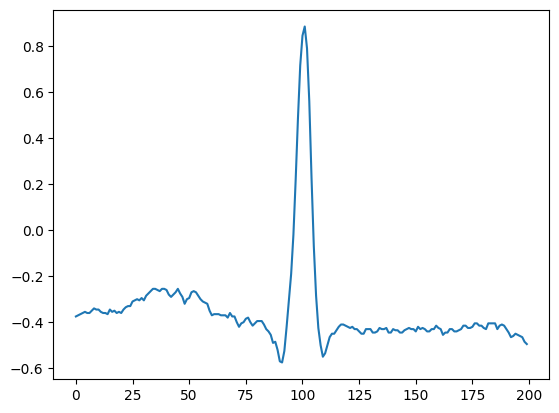

beat annotation  ->   N


In [95]:
plt.plot(l1_signal[idx-100:idx+100])
plt.show()
print("beat annotation  ->  ", ann.symbol[x])

#### annotation

In [96]:
ann = wfdb.rdann(
    r"C:\Users\Larissa\bsi\IC\databases\ecg\mit-bih-arrhythmia-database-1.0.0\100",
    "atr"
)

print(ann.sample[:10])
print(ann.symbol[:10])

[  18   77  370  662  946 1231 1515 1809 2044 2402]
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']


#### creating dataframe

In [97]:
df_annotations = pd.DataFrame({
    "sample": ann.sample,
    "symbol": ann.symbol
})
df_annotations['symbol'].value_counts()

symbol
N    2239
A      33
+       1
V       1
Name: count, dtype: int64

In [98]:
df_annotations[df_annotations['symbol']=='+']

,sample,symbol
0,18,+


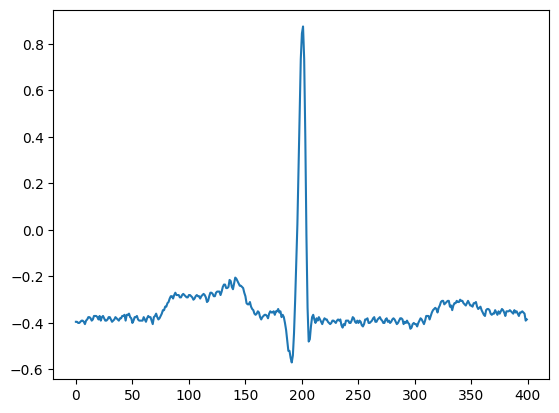

In [ ]:
#plotar esse sinal soooo vai la vc consegue
for 
a = df_annotations[df_annotations['symbol']=='A']['sample'].iloc[i]
plt.plot(l1_signal[a-200:a+200])

In [107]:
a

np.int64(18)